In [1]:
import pyspeckit
from pyspeckit.spectrum.models import lte_molecule
from astroquery.linelists import cdms

In [2]:
tbl = cdms.CDMS.get_species_table(use_cached=False)
tbl.add_index('tag')
tbl.loc[47523]

tag,molecule,#lines,lg(Q(1000)),lg(Q(500)),lg(Q(300)),lg(Q(225)),lg(Q(150)),lg(Q(75)),lg(Q(37.5)),lg(Q(18.75)),lg(Q(9.375)),lg(Q(5.000)),lg(Q(2.725))
int64,str27,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
47523,"CCl+, v=0",94,nan,nan,3.0236,2.8974,2.7213,2.4212,2.1224,1.8257,1.5336,1.2762,1.0409


In [3]:
from astropy import units as u
cdms.CDMS.query_lines(90*u.GHz, 100*u.GHz, molecule='CCl+, v=0', parse_name_locally=True)

FREQ,ERR,LGINT,DR,ELO,GUP,MOLWT,TAG,QNFMT,Ju,Ku,vu,F1u,F2u,F3u,Jl,Kl,vl,F1l,F2l,F3l,name,Lab
MHz,MHz,nm2 MHz,,1 / cm,,u,,,,,,,,,,,,,,,,
float64,float64,float64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str9,bool
95292.364,0.005,-6.0275,2,1.5895,4,47,5231,213,2,0,2,--,--,--,1,0,1,--,--,--,"CCl+, v=0",True
95292.613,0.003,-5.9941,2,1.5894,6,47,5231,213,2,0,3,--,--,--,1,0,3,--,--,--,"CCl+, v=0",True
95294.951,0.0038,-6.9483,2,1.5894,4,47,5231,213,2,0,2,--,--,--,1,0,3,--,--,--,"CCl+, v=0",False
95295.682,0.004,-6.0275,2,1.5895,2,47,5231,213,2,0,1,--,--,--,1,0,1,--,--,--,"CCl+, v=0",True
95296.055,0.001,-5.6261,2,1.5893,6,47,5231,213,2,0,3,--,--,--,1,0,2,--,--,--,"CCl+, v=0",True
95296.055,0.001,-5.3462,2,1.5894,8,47,5231,213,2,0,4,--,--,--,1,0,3,--,--,--,"CCl+, v=0",True
95298.38,0.004,-5.9203,2,1.5893,4,47,5231,213,2,0,2,--,--,--,1,0,2,--,--,--,"CCl+, v=0",True
95301.7017,0.0065,-6.7264,2,1.5893,2,47,5231,213,2,0,1,--,--,--,1,0,2,--,--,--,"CCl+, v=0",False


In [5]:
import sys
sys.path.append('/orange/adamginsburg/salt/code/')
from overplot_saltlines import overplot_saltlines

bad lines: []  [] GHz


In [48]:
import radio_beam

In [50]:
radio_beam.Beam(0.03*u.arcsec).jtok(350*u.GHz)

<Quantity 11084.99178008 K>

In [54]:
import glob
import numpy as np

stackspectra = []
for ii,fn in enumerate(glob.glob('/orange/adamginsburg/orion/2016.1.00165.S/FITS/stacked_spectra/*robust0.5_K.fits') + glob.glob('/orange/adamginsburg/orion/2016.1.00165.S/FITS/stacked_spectra/*B7.lb_spw*robust0.5*')):
    pysp = pyspeckit.Spectrum(fn)
    basename = os.path.basename(fn)
    spl = basename.split("_")
    pysp.specname = f'{spl[1]}_{spl[2]}_{spl[3]}_ccl'
    print(pysp.specname)
    pysp.data -= np.median(pysp.data)
    if 'B7' in pysp.specname:
        jtok = radio_beam.Beam(0.03*u.arcsec).jtok(350*u.GHz)
        pysp.data *= jtok.value
        pysp.unit = u.K
    stackspectra.append(pysp)

B6_spw3_robust0.5_ccl
B3_spw0_robust0.5_ccl
B6_spw1_robust0.5_ccl
B3_spw3_robust0.5_ccl
B3_spw2_robust0.5_ccl
B6_spw0_robust0.5_ccl
B3_spw1_robust0.5_ccl
B6_spw2_robust0.5_ccl
B7.lb_spw2_robust0.5.fits_ccl
B7.lb_spw3_robust0.5.fits_ccl
B7.lb_spw0_robust0.5.fits_ccl
B7.lb_spw1_robust0.5.fits_ccl


In [62]:
tbl

FREQ,ERR,LGINT,DR,ELO,GUP,MOLWT,TAG,QNFMT,Ju,Ku,vu,F1u,F2u,F3u,Jl,Kl,vl,F1l,F2l,F3l,name,Lab
MHz,MHz,nm2 MHz,,1 / cm,,u,,,,,,,,,,,,,,,,
float64,float64,float64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str9,bool
95292.364,0.005,-6.0275,2,1.5895,4,47,5231,213,2,0,2,--,--,--,1,0,1,--,--,--,"CCl+, v=0",True
95292.613,0.003,-5.9941,2,1.5894,6,47,5231,213,2,0,3,--,--,--,1,0,3,--,--,--,"CCl+, v=0",True
95294.951,0.0038,-6.9483,2,1.5894,4,47,5231,213,2,0,2,--,--,--,1,0,3,--,--,--,"CCl+, v=0",False
95295.682,0.004,-6.0275,2,1.5895,2,47,5231,213,2,0,1,--,--,--,1,0,1,--,--,--,"CCl+, v=0",True
95296.055,0.001,-5.6261,2,1.5893,6,47,5231,213,2,0,3,--,--,--,1,0,2,--,--,--,"CCl+, v=0",True
95296.055,0.001,-5.3462,2,1.5894,8,47,5231,213,2,0,4,--,--,--,1,0,3,--,--,--,"CCl+, v=0",True
95298.38,0.004,-5.9203,2,1.5893,4,47,5231,213,2,0,2,--,--,--,1,0,2,--,--,--,"CCl+, v=0",True
95301.7017,0.0065,-6.7264,2,1.5893,2,47,5231,213,2,0,1,--,--,--,1,0,2,--,--,--,"CCl+, v=0",False


In [64]:
cdms.CDMS.query_lines(4*u.GHz, 80*u.GHz,  molecule='CCl+, v=0', parse_name_locally=True)

FREQ,ERR,LGINT,DR,ELO,GUP,MOLWT,TAG,QNFMT,Ju,Ku,vu,F1u,F2u,F3u,Jl,Kl,vl,F1l,F2l,F3l,name,Lab
MHz,MHz,nm2 MHz,,1 / cm,,u,,,,,,,,,,,,,,,,
float64,float64,float64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str9,bool
47645.681,0.002,-6.3236,2,0.0,4,47,5231,213,1,0,2,--,--,--,0,0,2,--,--,--,"CCl+, v=0",False
47649.1071,0.001,-6.1474,2,0.0,6,47,5231,213,1,0,3,--,--,--,0,0,2,--,--,--,"CCl+, v=0",False
47651.6958,0.0039,-6.6245,2,0.0,2,47,5231,213,1,0,1,--,--,--,0,0,2,--,--,--,"CCl+, v=0",False


In [57]:
tbl = cdms.CDMS.query_lines(80*u.GHz, 400*u.GHz,  molecule='CCl+, v=0', parse_name_locally=True)
print(len(tbl))
freqs = tbl['FREQ'].quantity
names = np.array([f"J={row['Ju']}-{row['Jl']} v={row['vu']}-{row['vl']}" for row in tbl])

50


In [58]:
import pylab as pl
pl.rcParams['figure.facecolor'] = 'w'

B6_spw3_robust0.5_ccl
B3_spw0_robust0.5_ccl
B6_spw1_robust0.5_ccl
B3_spw3_robust0.5_ccl
B3_spw2_robust0.5_ccl
B6_spw0_robust0.5_ccl
B3_spw1_robust0.5_ccl
B6_spw2_robust0.5_ccl
B7.lb_spw2_robust0.5.fits_ccl
B7.lb_spw3_robust0.5.fits_ccl
B7.lb_spw0_robust0.5.fits_ccl
B7.lb_spw1_robust0.5.fits_ccl


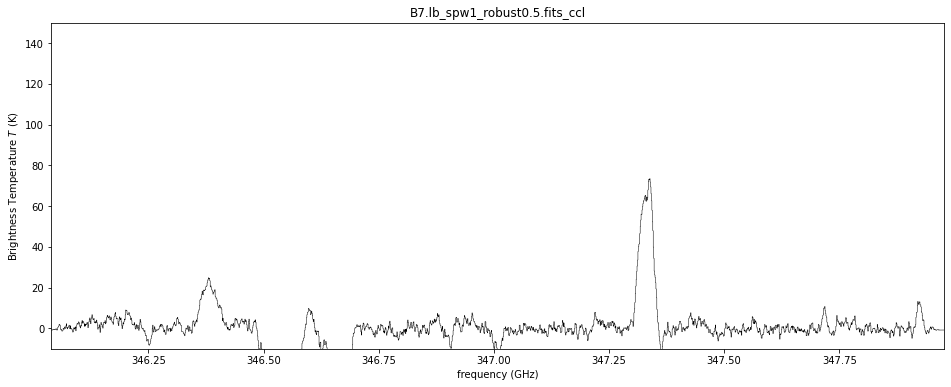

In [59]:
overplot_saltlines(stackspectra, vcen=5*u.km/u.s, savepath='/orange/adamginsburg/salt/orion/spectra/figures', ymin=-10, ymax=150, linefreqs=freqs, linetexnames=names)

In [60]:
from IPython.display import display, Image

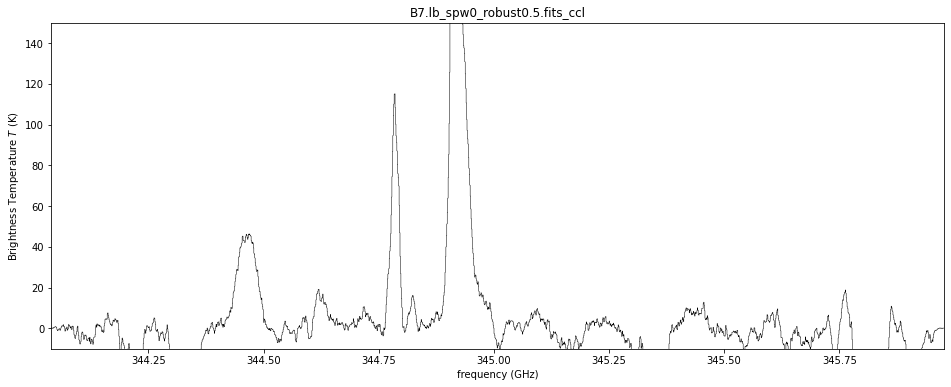

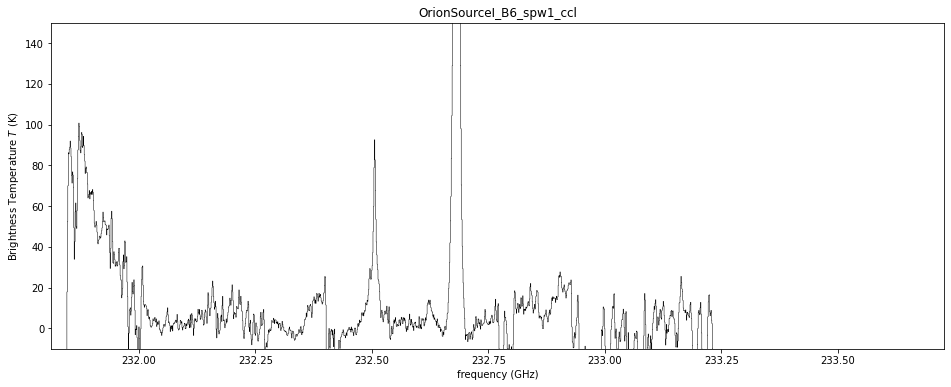

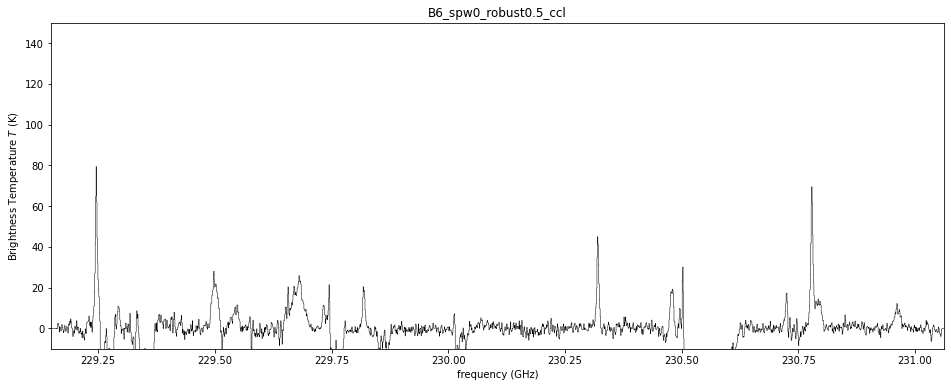

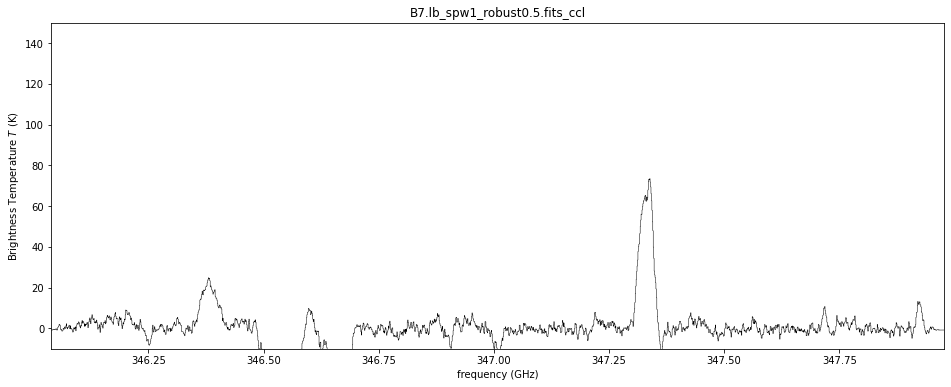

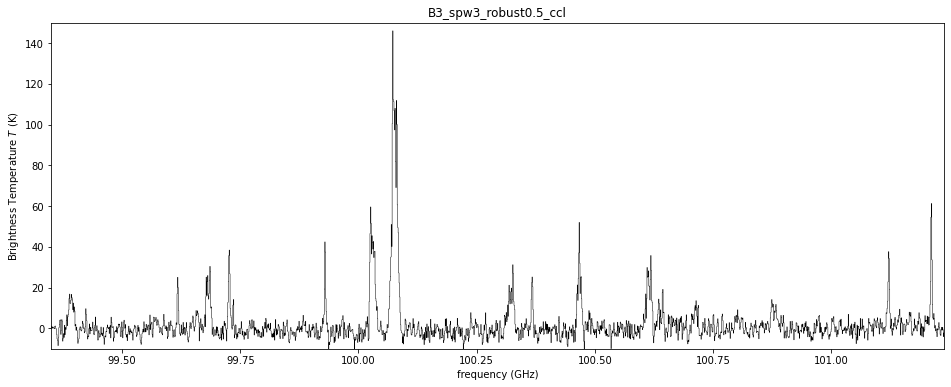

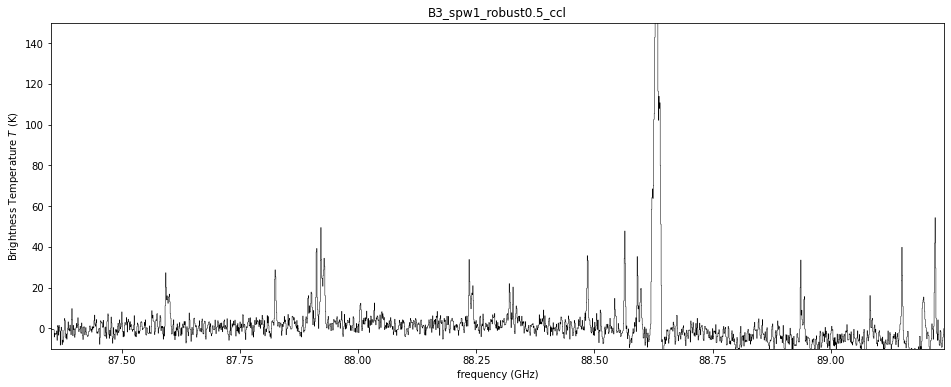

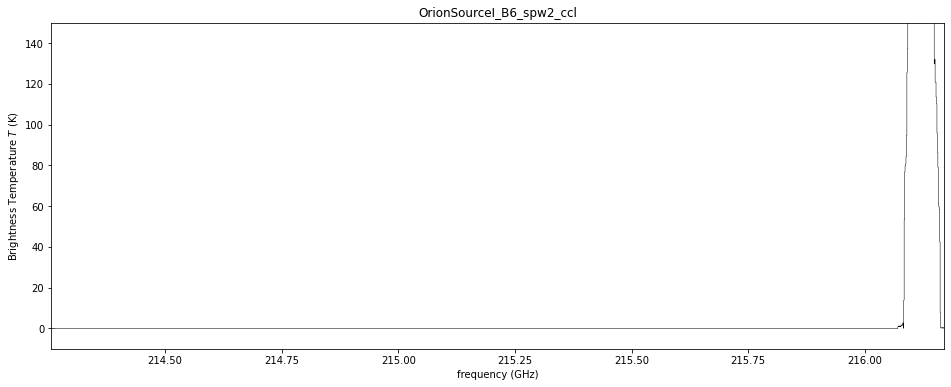

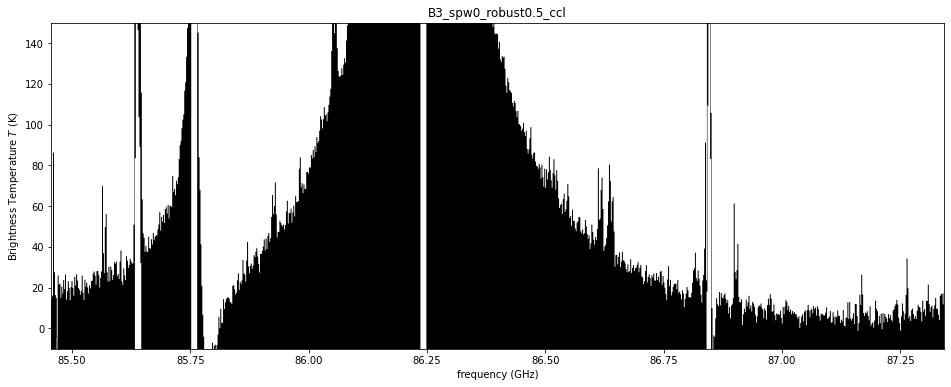

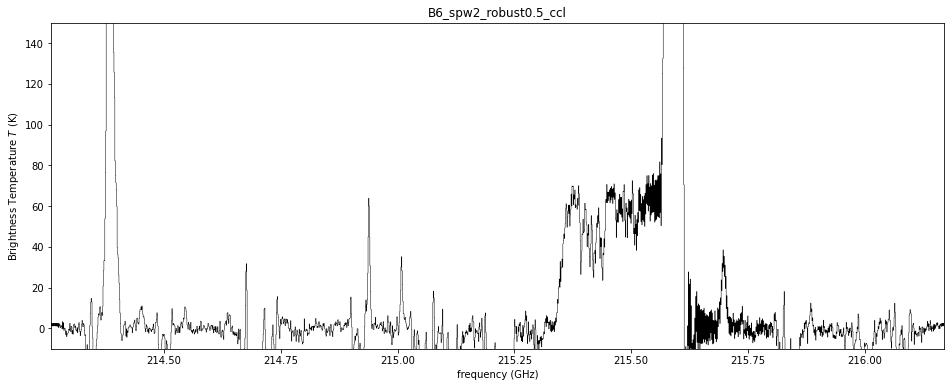

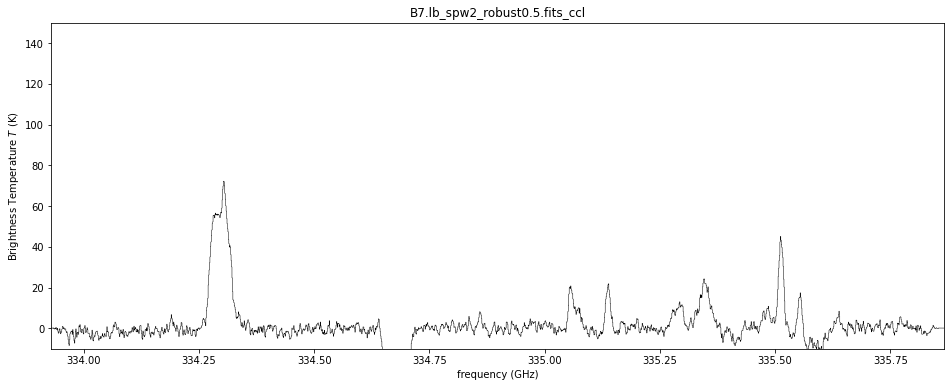

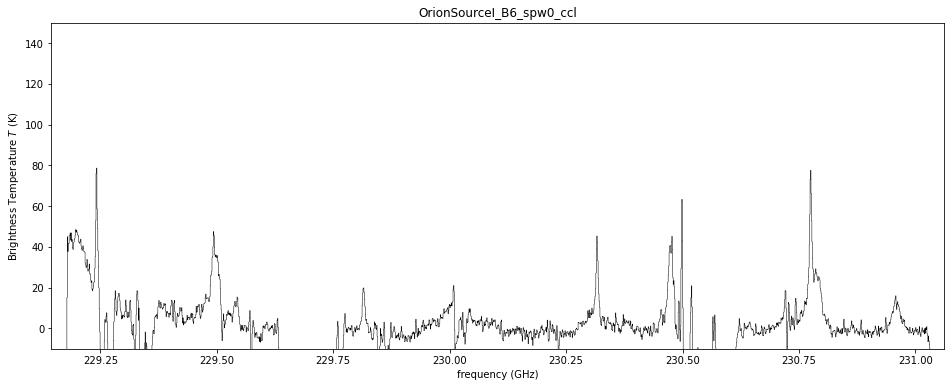

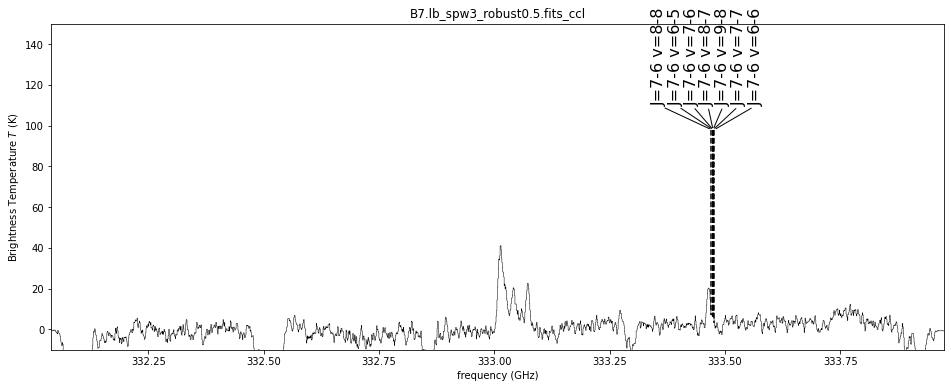

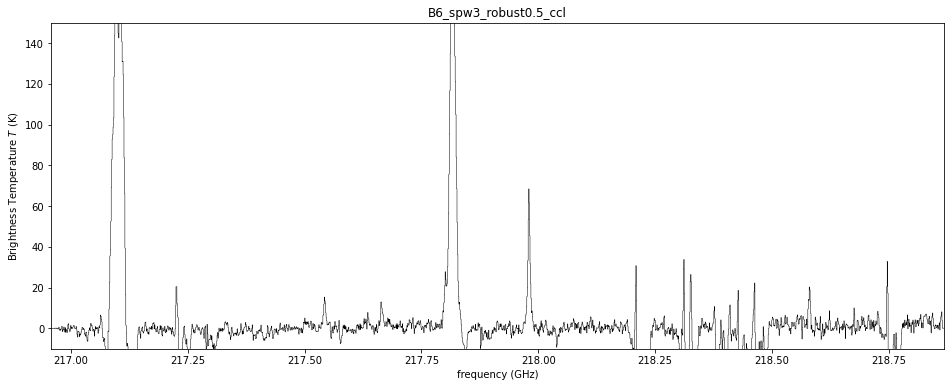

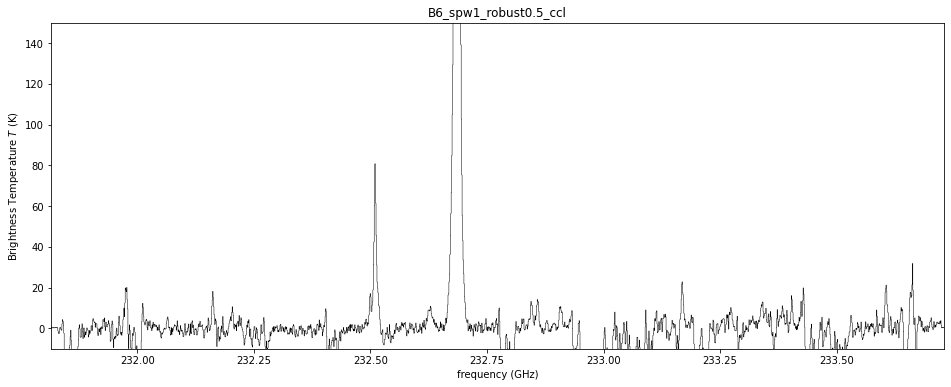

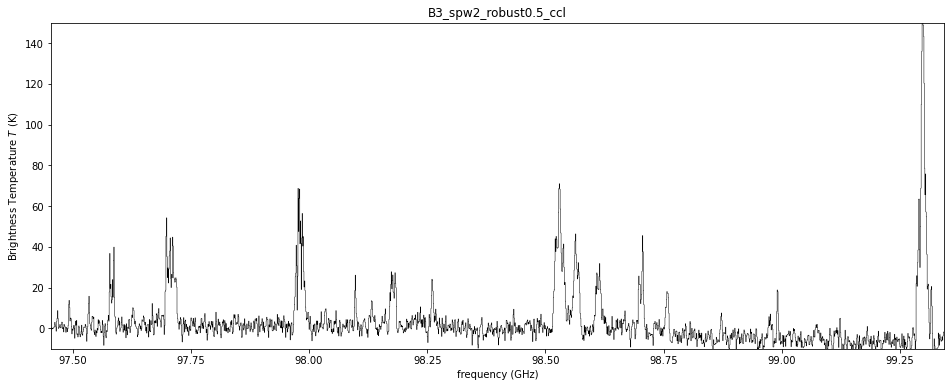

In [61]:
for fn in glob.glob('/orange/adamginsburg/salt/orion/spectra/figures/color*ccl.png'):
    display(Image(fn))

In [44]:
sp = pyspeckit.Spectrum('/orange/adamginsburg/orion/2016.1.00165.S/FITS/stacked_spectra/OrionSourceI_B7_spw3_robust0.5.fits')

In [ ]:
sp.data.to

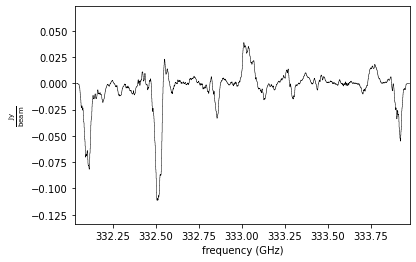

In [45]:
sp.plotter()

# Fixing CDMS query tool to include new molecules

In [14]:
url='https://cdms.astro.uni-koeln.de/classic/entries/partition_function.html'

In [75]:
import requests
resp = requests.get(url)
from astropy.table import Table
from astropy.io import ascii
header = resp.text.split("\n")[13]
data = resp.text.split("\n")[15:-5]
#Table(names=header.split(), data=[row.replace(", ", ",_").split() for row in data])
ascii.read(resp.text, header_start=12, data_start=15, data_end=-5, format='fixed_width', delimiter=' ')[:4]

tag,molecule,#lines,lg(Q(1000)),lg(Q(500)),lg(Q(300)),lg(Q(225)),lg(Q(150)),lg(Q(75)),lg(Q(37.5)),lg(Q(18.75)),lg(Q(9.375)),lg(Q(5.000)),lg(Q(2.725))
int64,str8,str6,str6,str6,float64,str6,float64,str6,str7,str6,str6,str6,str6
45,H2D+,196,---,2.2148,1.8834,1.6986,1.4401,0.9882,0.4919,0.0846,0.0016,0.0000,0.0000
55,HD2+,163,---,---,1.9098,1.7243,1.4652,1.0326,0.6405,0.3772,0.3049,0.3011,0.3010
55,HeH+,18,1.3320,1.0335,0.8192,0.7015,0.5406,0.2874,0.0904,0.0075,0.0000,---,---
125,C-atom,2,0.9359,0.9177,0.8939,0.8744,0.8363,0.7295,0.5494,0.3075,0.0962,0.0114,0.0002


In [74]:
resp.text.split("\n")[13].index(" ")

0

In [47]:
len(resp.text.split("\n")[15].split())

14

In [48]:
len(resp.text.split("\n")[13].split())

14

In [61]:
len(row.split())
resp.text.split("\n")[25].split("\t")

[' 13504 CH+, v=1-0                   35          ---       1.4051       1.1861       1.0641       0.8942       0.6124       0.3512       0.1342       0.0177       0.0004       0.0000']

In [63]:
for ii, row in enumerate(resp.text.split("\n")[15:-5]):
    if len(row.replace(", ", ",_").split()) != 14:
        print(ii, row)

125  29506 N2H+, v=0; recommended       47          ---       3.4108       3.1143       2.9692       2.7844       2.4842       2.1875       1.8952       1.6116       1.3696       1.1633
317  43504 C2H3NH2, w.in 0+,-         6659          ---          ---       4.3583       4.1570       3.8670       3.3508       2.8180       2.3105       1.8492          ---          ---
339  44504 Ethylene oxide            15797          ---          ---       4.5955       4.4080       4.1439       3.6928       3.2424       2.7934       2.3470       1.9464       1.5677
516  51522 HC3N, nu3 band              191          ---          ---       3.1383       3.0133       2.8373       2.5364       2.2358       1.9356       1.6363          ---          ---
517  51523 HC3N, nu2 band              205          ---          ---       3.1383       3.0133       2.8373       2.5364       2.2358       1.9356       1.6363          ---          ---
518  51524 HC3N, nu1 band              261          ---          ---  

In [82]:
resp.text.split("\n")[13]

' tag   molecule                 #lines   lg(Q(1000))  lg(Q(500))   lg(Q(300))   lg(Q(225))   lg(Q(150))    lg(Q(75))  lg(Q(37.5))   lg(Q(18.75))  lg(Q(9.375))  lg(Q(5.000))  lg(Q(2.725))'

In [88]:
resp.text.split("\n")[13].find("#")

32

In [93]:
s = "x"
s.find?

Docstring:
S.find(sub[, start[, end]]) -> int

Return the lowest index in S where substring sub is found,
such that sub is contained within S[start:end].  Optional
arguments start and end are interpreted as in slice notation.

Return -1 on failure.
Type:      builtin_function_or_method


In [107]:
resp.text.split("\n")[13].find(" lg", 174)

-1

In [87]:
resp.text.split("\n")[13].split()

['tag',
 'molecule',
 '#lines',
 'lg(Q(1000))',
 'lg(Q(500))',
 'lg(Q(300))',
 'lg(Q(225))',
 'lg(Q(150))',
 'lg(Q(75))',
 'lg(Q(37.5))',
 'lg(Q(18.75))',
 'lg(Q(9.375))',
 'lg(Q(5.000))',
 'lg(Q(2.725))']

In [84]:
resp.text.split("\n")[15]

'  3501 HD                           20       1.2115       0.9135       0.7026       0.5876       0.4322       0.1964       0.0406       0.0014       0.0000       0.0000       0.0000'

In [86]:
resp.text.split("\n")[-6]

'171501 HC13N                       199          ---          ---       4.7667       4.6418       4.4657       4.1646       3.8636       3.5626       3.2616          ---          ---'

In [9]:
url='https://cdms.astro.uni-koeln.de/classic/entries/partition_function.html'
import requests
from astropy.io import ascii
resp = requests.get(url)
resp.raise_for_status()
tbl = ascii.read(resp.text, header_start=None, data_start=15, data_end=-5,
                 names=['tag', 'molecule', '#lines', 'lg(Q(1000))', 'lg(Q(500))', 'lg(Q(300))', 'lg(Q(225))', 'lg(Q(150))', 'lg(Q(75))', 'lg(Q(37.5))', 'lg(Q(18.75))', 'lg(Q(9.375))', 'lg(Q(5.000))', 'lg(Q(2.725))'],
                 col_starts=(0, 7, 34, 41, 53, 66, 79, 92, 106, 117, 131, 145, 159, 173),
                 format='fixed_width', delimiter=' ')
tbl

tag,molecule,#lines,lg(Q(1000)),lg(Q(500)),lg(Q(300)),lg(Q(225)),lg(Q(150)),lg(Q(75)),lg(Q(37.5)),lg(Q(18.75)),lg(Q(9.375)),lg(Q(5.000)),lg(Q(2.725))
int64,str27,int64,str6,str6,float64,str6,float64,str6,str14,str6,str6,str6,str6
4501,H2D+,196,---,2.2148,1.8834,1.6986,1.4401,0.9882,0.4919,0.0846,0.0016,0.0000,0.0000
5501,HD2+,163,---,---,1.9098,1.7243,1.4652,1.0326,0.6405,0.3772,0.3049,0.3011,0.3010
5502,HeH+,18,1.3320,1.0335,0.8192,0.7015,0.5406,0.2874,0.0904,0.0075,0.0000,---,---
12501,C-atom,2,0.9359,0.9177,0.8939,0.8744,0.8363,0.7295,0.5494,0.3075,0.0962,0.0114,0.0002
12502,BH,15,---,---,1.2565,1.1339,0.9629,0.6781,0.4105,0.1794,0.0334,---,---
12503,C+,1,0.7521,0.7270,0.6947,0.6690,0.6209,0.5032,0.3713,0.3077,0.3011,0.3010,0.3010
13501,C-13,7,1.2369,1.2188,1.195,1.1755,1.1374,1.0305,0.8504,0.6085,0.3972,0.3125,0.3012
13502,CH,513,---,2.3005,2.0822,1.9608,1.7924,1.5175,1.2752,1.0864,0.9523,0.9013,0.8906
13503,CH+,19,---,1.4051,1.1861,1.0641,0.8942,0.6124,0.3512,0.1342,0.0177,0.0004,0.0000


In [10]:
tbl['#lines'].astype('int')

196
163
18
2
15
1
7
513
19
35
27
